# Latent VLA: LAM vs VLM latent action comparison
运行说明：按训练同样方式加载 VLM+processor（cfg.model_id 指向你训练后的 HF 目录）和 LAM teacher，取 val split 一个 batch，对比 LAM indices 与 VLM 生成的 latent indices，并可视化。

In [1]:
import os
import torch
from torch.utils.data import DataLoader
from vla_scripts.train import TrainConfig

# === 基础配置 ===
# 直接将 model_id 指向训练好的 checkpoint 目录（包含 VLM 权重与 latent_vla_extra.pt）
# ckpt_dir = "/mnt/project_rlinf/jlchen/code/UniVLA/vla_scripts/world_vla_log/0115_194424+weights+libero+lr-0.0001+frzVis+frzLLM+unfrzLast4+frzEmb--finetune_libero_emb_detach/checkpoints/step-035000"
# vla_yaml_path = "/mnt/project_rlinf/jlchen/code/UniVLA/vla_scripts/vla_log/0114_155304+vla_emb_unfreeze_llm4_dec_gt_hist_lam_plus/vla_emb.yaml"
ckpt_dir = "/mnt/project_rlinf/jlchen/code/UniVLA/vla_scripts/world_vla_log/0119_143633+checkpoints+libero_object_no_noops+lr-0.0001+frzVis+frzLLM+unfrzLast4+frzEmb--finetune_libero_object_detach_no_aug_no_hist_q99/checkpoints/step-050000"
vla_yaml_path = "/mnt/project_rlinf/jlchen/code/UniVLA/vla_scripts/vla_log/0114_155304+vla_emb_unfreeze_llm4_dec_gt_hist_lam_plus/vla_emb.yaml"
# ckpt_dir = "/mnt/project_rlinf/jlchen/code/UniVLA/vla_scripts/vla_log/0108_160945+vla_emb_unfreeze_llm4_dec2000_gt/checkpoints/checkpoint-85000"
# vla_yaml_path = "/mnt/project_rlinf/jlchen/code/UniVLA/vla_scripts/vla_log/0108_160945+vla_emb_unfreeze_llm4_dec2000_gt/vla_emb.yaml"
# ckpt_dir = "/mnt/project_rlinf/jlchen/code/UniVLA/vla_scripts/vla_log/0107_103411+vla_emb_unfreeze_llm4_libero_90/checkpoints/checkpoint-10000"
# vla_yaml_path = "/mnt/project_rlinf/jlchen/code/UniVLA/vla_scripts/vla_log/0107_103411+vla_emb_unfreeze_llm4_libero_90/vla_emb.yaml"
# ckpt_dir = "/mnt/project_rlinf/jlchen/code/UniVLA/vla_scripts/vla_log/0111_000132+vla_emb_unfreeze_llm4_dec2000_gt_no_history/checkpoints/checkpoint-40000"
# vla_yaml_path = "/mnt/project_rlinf/jlchen/code/UniVLA/vla_scripts/vla_log/0111_000132+vla_emb_unfreeze_llm4_dec2000_gt_no_history/vla_emb.yaml"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.cuda.set_device(0 if torch.cuda.is_available() else "cpu")
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
print(f"Using device: {device}")

# 复用训练时配置：直接把 model_id 设为 checkpoint 目录
cfg = TrainConfig()
cfg.model_id = ckpt_dir

# 训练时使用的 VLA YAML（用于覆盖 TrainConfig 默认值，尤其是 supervise_quantized / loss 配置等）
# 注意：保持 cfg.model_id=ckpt_dir，不会被 YAML 中的 base model_id 覆盖


# cfg.lam_ckpt_path= "/mnt/project_rlinf/jlchen/code/UniVLA/latent_action_model/logs/dino_base_4q_32_norep/version_0/checkpoints/epoch=4.ckpt"
# cfg.lam_yaml_path= "/mnt/project_rlinf/jlchen/code/UniVLA/latent_action_model/logs/dino_base_4q_32_norep/version_0/dino_base.yaml"
# lam_ckpt_path= "/mnt/project_rlinf/jlchen/code/UniVLA/latent_action_model/logs/dino_base_ae_bigwin/version_0/checkpoints/epoch=21.ckpt"
# lam_yaml_path= "/mnt/project_rlinf/jlchen/code/UniVLA/latent_action_model/logs/dino_base_ae_bigwin/version_0/dino_base_ae.yaml"

# 减小 batch 以便快速推理
cfg.per_device_eval_batch_size = 6
cfg.use_history_frame = True  # 如需带 history，可设为 True
# cfg.debug_repeat_batch = False  # 如需稳定复现，可设为整数
# cfg.training_phase = "lam_2f"
# cfg.data_mix = "libero_object_no_noops"
# cfg.use_history_frame = False
# 方便 notebook 重复运行：清理可能的分布式状态
os.environ.pop("WORLD_SIZE", None)
os.environ.pop("RANK", None)
os.environ.pop("LOCAL_RANK", None)


2026-01-20 16:38:19.697432: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-01-20 16:38:19.742439: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-01-20 16:38:19.742479: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-01-20 16:38:19.744060: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-01-20 16:38:19.751768: I tensorflow/core/platform/cpu_feature_guar

Using device: cuda


In [2]:
from prismatic.vla.latent_vla_model import LatentVLAModel

# 加载 VLM + LAM（保持 LAM eval/frozen）
latent_vla_model, processor = LatentVLAModel.from_config(
    cfg,
    overwatch=None,
    debug_mode=False,
    yaml_path=vla_yaml_path,
    preserve_checkpoint_model_id=True,
)
latent_vla_model = latent_vla_model.to(device).eval()

print(f"Loaded model_id: {cfg.model_id}")
print(f"cfg.supervise_quantized: {bool(getattr(cfg, 'supervise_quantized', False))}")
print(f"model.supervise_quantized: {bool(getattr(latent_vla_model, 'supervise_quantized', False))}")
print(f"model.num_queries: {getattr(latent_vla_model, 'num_queries', None)}")
print(f"LAM num_queries: {getattr(latent_vla_model.lam, 'num_queries', None)}")
print(f"Has act_query: {getattr(latent_vla_model, 'act_query', None) is not None}")
print(f"Has vlm_to_lam: {getattr(latent_vla_model, 'vlm_to_lam', None) is not None}")
print(f"Action token begin id: {latent_vla_model.action_token_begin_id}")
print(cfg.use_history_frame)
print(latent_vla_model.vlm)


[LatentVLAModel] applied yaml overrides from `/mnt/project_rlinf/jlchen/code/UniVLA/vla_scripts/vla_log/0114_155304+vla_emb_unfreeze_llm4_dec_gt_hist_lam_plus/vla_emb.yaml` (preserve_model_id=True)
🔄 加载基础 VLM `/mnt/project_rlinf/jlchen/code/UniVLA/vla_scripts/world_vla_log/0119_143633+checkpoints+libero_object_no_noops+lr-0.0001+frzVis+frzLLM+unfrzLast4+frzEmb--finetune_libero_object_detach_no_aug_no_hist_q99/checkpoints/step-050000`（HF from_pretrained, generic）
`torch_dtype` is deprecated! Use `dtype` instead!
🔄 加载 LAM（yaml=`/mnt/project_rlinf/jlchen/code/UniVLA/latent_action_model/logs/dino_base_ae_bigwin/version_0/dino_base_ae.yaml`）
[LatentVLAModel] tokenizer vocab_size=151702, vlm.num_embeddings=151936
[LatentVLAModel] loading extra wrapper weights from `/mnt/project_rlinf/jlchen/code/UniVLA/vla_scripts/world_vla_log/0119_143633+checkpoints+libero_object_no_noops+lr-0.0001+frzVis+frzLLM+unfrzLast4+frzEmb--finetune_libero_object_detach_no_aug_no_hist_q99/checkpoints/step-050000/lat

Loaded model_id: /mnt/project_rlinf/jlchen/code/UniVLA/vla_scripts/world_vla_log/0119_143633+checkpoints+libero_object_no_noops+lr-0.0001+frzVis+frzLLM+unfrzLast4+frzEmb--finetune_libero_object_detach_no_aug_no_hist_q99/checkpoints/step-050000
cfg.supervise_quantized: True
model.supervise_quantized: True
model.num_queries: 1
LAM num_queries: 1
Has act_query: True
Has vlm_to_lam: True
Action token begin id: 151669
True
Qwen3VLForConditionalGeneration(
  (model): Qwen3VLModel(
    (visual): Qwen3VLVisionModel(
      (patch_embed): Qwen3VLVisionPatchEmbed(
        (proj): Conv3d(3, 1024, kernel_size=(2, 16, 16), stride=(2, 16, 16))
      )
      (pos_embed): Embedding(2304, 1024)
      (rotary_pos_emb): Qwen3VLVisionRotaryEmbedding()
      (blocks): ModuleList(
        (0-23): 24 x Qwen3VLVisionBlock(
          (norm1): LayerNorm((1024,), eps=1e-06, elementwise_affine=True)
          (norm2): LayerNorm((1024,), eps=1e-06, elementwise_affine=True)
          (attn): Qwen3VLVisionAttention(


In [3]:
# 重新设置数据集参数（因为 from_config 会从 yaml 覆盖 cfg）
cfg.data_mix = "libero_object_no_noops"
print(f"重新设置 cfg.data_mix = {cfg.data_mix}")
cfg.image_aug=False
cfg.use_history_frame=True
cfg.window_size=10



重新设置 cfg.data_mix = libero_object_no_noops


In [4]:
from prismatic.vla import get_latent_vla_dataset_and_collator

# 目标序列长度与训练保持一致（InternVL 系列用 350）
target_seq_len = 350 if "InternVL" in cfg.model_id else 250
train_dataset, val_dataset, collator = get_latent_vla_dataset_and_collator(
    cfg.data_root_dir,
    cfg.data_mix,
    processor=processor,
    padding_side="right",
    predict_stop_token=False,
    shuffle_buffer_size=cfg.shuffle_buffer_size,
    episodic=False,
    image_aug=False,
    training_phase=cfg.training_phase,
    latent_action_num_queries=latent_vla_model.lam.num_queries,
    debug_repeat_batch=cfg.debug_repeat_batch,
    target_seq_len=target_seq_len,
    use_history_frame=cfg.use_history_frame,
    window_size=cfg.window_size,
)

# 仅用 val split 取一个 batch
dataloader = DataLoader(
    val_dataset,
    batch_size=cfg.per_device_eval_batch_size,
    num_workers=0,
    pin_memory=True,
    collate_fn=collator,
)

print("DataLoader ready (val split).")


Load dataset info from /mnt/project_rlinf/jlchen/datasets/libero_object_no_noops/1.0.0


Constructing tf.data.Dataset libero_object for split all, from /mnt/project_rlinf/jlchen/datasets/libero_object_no_noops/1.0.0
2026-01-20 16:38:50.799653: I tensorflow/core/grappler/optimizers/data/replicate_on_split.cc:32] Running replicate on split optimization
[*] Loading existing dataset statistics from /mnt/project_rlinf/jlchen/datasets/libero_object_no_noops/1.0.0/dataset_statistics_25a482fd2cea7cb62663832fa767aded4e382d6fc1d5df2530767e435edfbfdc.json.
Constructing tf.data.Dataset libero_object for split train, from /mnt/project_rlinf/jlchen/datasets/libero_object_no_noops/1.0.0
2026-01-20 16:38:51.266508: I tensorflow/core/grappler/optimizers/data/replicate_on_split.cc:32] Running replicate on split optimization
[*] Threads per Dataset: [1]
[*] Reads per Dataset: [1]
[*] Constructing datasets...
Load dataset info from /mnt/project_rlinf/jlchen/datasets/libero_object_no_noops/1.0.0
Constructing tf.data.Dataset libero_object for split train, from /mnt/project_rlinf/jlchen/datasets


######################################################################################
# Loading the following 1 datasets (incl. sampling weight):                         #
# libero_object_no_noops: ==================================================1.000000 #
######################################################################################



2026-01-20 16:38:51.733440: I tensorflow/core/grappler/optimizers/data/replicate_on_split.cc:32] Running replicate on split optimization
[*] Applying frame transforms on dataset...
Load dataset info from /mnt/project_rlinf/jlchen/datasets/libero_object_no_noops/1.0.0
Constructing tf.data.Dataset libero_object for split all, from /mnt/project_rlinf/jlchen/datasets/libero_object_no_noops/1.0.0
2026-01-20 16:38:53.714157: I tensorflow/core/grappler/optimizers/data/replicate_on_split.cc:32] Running replicate on split optimization
[*] Loading existing dataset statistics from /mnt/project_rlinf/jlchen/datasets/libero_object_no_noops/1.0.0/dataset_statistics_25a482fd2cea7cb62663832fa767aded4e382d6fc1d5df2530767e435edfbfdc.json.
Constructing tf.data.Dataset libero_object for split train, from /mnt/project_rlinf/jlchen/datasets/libero_object_no_noops/1.0.0
2026-01-20 16:38:53.850786: I tensorflow/core/grappler/optimizers/data/replicate_on_split.cc:32] Running replicate on split optimization
[*]


######################################################################################
# Loading the following 1 datasets (incl. sampling weight):                         #
# libero_object_no_noops: ==================================================1.000000 #
######################################################################################



[*] Applying frame transforms on dataset...


DataLoader ready (val split).


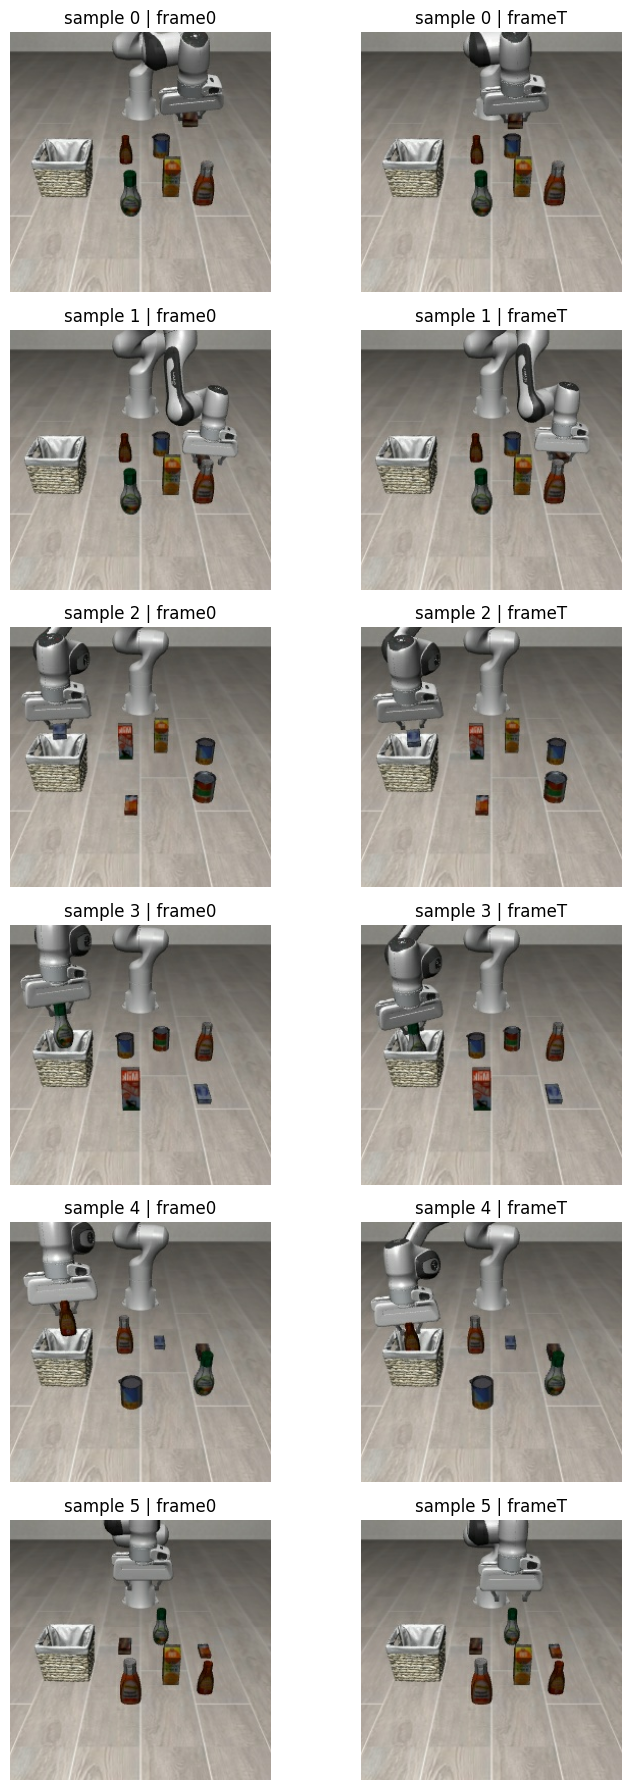

In [5]:
# 可视化当前 batch 的所有原图（history/frame0 与 target/frame-last）
import math
import matplotlib.pyplot as plt

# ===== 取一个 batch 并跑推理，对比 LAM teacher vs VLM student =====
# 默认用持久迭代器；想换 batch 只需再次运行本 cell（会拿下一个批次）。若需回到首批，将 reset_iterator 设为 True。
reset_iterator = False
if reset_iterator or 'data_iter' not in globals():
    data_iter = iter(dataloader)
batch = next(data_iter)

# 移动到设备，处理 pixel_values 的 dict 情况
def _to_device(x):
    if isinstance(x, dict):
        return {k: v.to(device, non_blocking=True) for k, v in x.items()}
    return x.to(device, non_blocking=True)

pixel_values = _to_device(batch["pixel_values"])
image_grid_thw = batch.get("image_grid_thw")
if image_grid_thw is not None:
    image_grid_thw = _to_device(image_grid_thw)

model_inputs = {
    "input_ids": batch["input_ids"].to(device, non_blocking=True),
    "attention_mask": batch["attention_mask"].to(device, non_blocking=True),
    "pixel_values": pixel_values,
    "image_grid_thw": image_grid_thw,
    "act_placeholder_mask": batch["act_placeholder_mask"].to(device, non_blocking=True),
    "lam_videos": batch["lam_videos"].to(device, non_blocking=True),
    "lam_states": batch["lam_states"].to(device, non_blocking=True),
    "lam_dec_videos": None,
    "lam_dataset_ids": batch.get("dataset_ids", None),
}

lam_videos = model_inputs["lam_videos"]  # [B, T, C, H, W], 已在 GPU
B, T, C, H, W = lam_videos.shape
# 归一化参数匹配 lam_videos[:,0] 的形状 [B,3,H,W]
mean = torch.tensor([0.485, 0.456, 0.406], device=lam_videos.device).view(1, 3, 1, 1)
std = torch.tensor([0.229, 0.224, 0.225], device=lam_videos.device).view(1, 3, 1, 1)

# 取首帧与末帧（防止广播产生额外维度）
first_frames = (lam_videos[:, 0] * std + mean).clamp(0, 1)
last_frames = (lam_videos[:, -1] * std + mean).clamp(0, 1)
if first_frames.dim() == 5:
    first_frames = first_frames.squeeze(1)
if last_frames.dim() == 5:
    last_frames = last_frames.squeeze(1)
first_frames = first_frames.cpu()
last_frames = last_frames.cpu()

cols = 2
rows = B
fig, axes = plt.subplots(rows, cols, figsize=(4*cols, 3*rows))
if rows == 1:
    axes = axes.reshape(1, -1)
for i in range(B):
    axes[i, 0].imshow(first_frames[i].permute(1, 2, 0))
    axes[i, 0].axis('off')
    axes[i, 0].set_title(f"sample {i} | frame0")
    axes[i, 1].imshow(last_frames[i].permute(1, 2, 0))
    axes[i, 1].axis('off')
    axes[i, 1].set_title(f"sample {i} | frameT")
plt.tight_layout()
plt.show()
plt.close()



In [6]:
import math
from typing import Dict, Any
import torch.nn.functional as F


# sanity check: 占位符数量应与训练时 num_queries 一致
Q_batch = int(batch["act_placeholder_mask"][0].sum().item())
assert int(getattr(latent_vla_model, "num_queries", -1)) == Q_batch, (
    f"placeholder Q mismatch: batch={Q_batch}, model.num_queries={getattr(latent_vla_model, 'num_queries', None)}"
)

with torch.no_grad():
    supervise_q = bool(getattr(latent_vla_model, "supervise_quantized", False))
    if supervise_q:
        # 直接回归动作 embedding；不需要生成 token
        out = latent_vla_model.predict_latent_actions(
            **model_inputs,
            strict_placeholder_count=True,
        )
        # 强校验：supervise_quantized 路径不应触发自回归 generate
        if not isinstance(out, dict):
            raise TypeError(f"predict_latent_actions() should return a dict, got {type(out)}")
        if "vlm_latent_idx" in out:
            raise RuntimeError(
                "supervise_quantized=True but got `vlm_latent_idx` in output; "
                "this indicates the token-generation path was taken unexpectedly."
            )
        if "pred_quantized" not in out or out["pred_quantized"] is None:
            raise RuntimeError("supervise_quantized=True but `pred_quantized` is missing/None in output.")
        pred_quantized = out["pred_quantized"]  # [B, Q, D]
        lam_idx = out.get("lam_latent_idx", None)
        lam_quantized = out.get("lam_quantized", None)
    else:
        out = latent_vla_model.predict_latent_actions(
            **model_inputs,
            strict_placeholder_count=True,
            generate_kwargs={
                "do_sample": False,
                "max_new_tokens": latent_vla_model.num_queries,
                "min_new_tokens": latent_vla_model.num_queries,
            },
        )
        lam_idx = out["lam_latent_idx"]  # [B, Q]
        vlm_idx = out["vlm_latent_idx"]  # [B, Q]

# 用同一个 `supervise_q` 分支变量，避免中途改动/配置漂移造成的歧义
if supervise_q:
    B, Q, D = pred_quantized.shape
    placeholder_counts = batch["act_placeholder_mask"].sum(dim=1).tolist()
    print(f"lam_videos raw shape: {tuple(batch['lam_videos'].shape)}, lam_states raw shape: {tuple(batch['lam_states'].shape)}")
    print(f"Batch size: {B}, num_latents (Q): {Q}, embed dim: {D}")
    print(f"Placeholder counts per sample: {placeholder_counts}")

    if lam_quantized is not None:
        # 对齐的 teacher embedding，可做余弦/ MSE 对比
        lam_quantized = lam_quantized.to(pred_quantized.device)
        cos = F.cosine_similarity(pred_quantized, lam_quantized, dim=-1).mean().item()
        mse = F.mse_loss(pred_quantized, lam_quantized).item()
        print(f"lam_quantized mean: {lam_quantized.abs().mean()}, lam_quantized std: {lam_quantized.abs().std()}")
        print(f"Mean cosine(pred, teacher): {cos:.4f}")
        print(f"MSE(pred, teacher): {mse:.6f}")
    if lam_idx is not None:
        print(f"Teacher indices shape: {tuple(lam_idx.shape)}")

    latency_compare = {
        "pred_quantized": pred_quantized,
        "lam_idx": lam_idx,
        "lam_quantized": lam_quantized,
    }
else:
    assert lam_idx.shape == vlm_idx.shape
    B, Q = lam_idx.shape

    # 逐位精度与整段完全匹配
    match_matrix = (lam_idx == vlm_idx)
    token_acc = match_matrix.float().mean().item()
    exact_match = match_matrix.all(dim=1).float().mean().item()

    placeholder_counts = batch["act_placeholder_mask"].sum(dim=1).tolist()

    # 辅助：将 indices 转为 token 字符串
    start_id = latent_vla_model.action_token_begin_id
    def to_tokens(idx_row):
        return [f"<ACT_{int(i.item())}>" for i in idx_row]

    def to_ids(idx_row):
        return [int(i.item()) for i in idx_row]

    def to_token_ids(idx_row):
        return [start_id + int(i.item()) for i in idx_row]

    print(f"lam_videos raw shape: {tuple(batch['lam_videos'].shape)}, lam_states raw shape: {tuple(batch['lam_states'].shape)}")
    print(f"Batch size: {B}, num_latents (Q): {Q}")
    print(f"Token-level accuracy: {token_acc:.4f}")
    print(f"Exact-match (all Q positions): {exact_match:.4f}")
    print(f"Placeholder counts per sample: {placeholder_counts}")

    # 展示前若干样本的 teacher vs student

    for i in range(B):
        teacher_tokens = to_tokens(lam_idx[i])
        student_tokens = to_tokens(vlm_idx[i])
        print(f"\nSample {i}")
        print(f"teacher: {teacher_tokens}")
        print(f"student: {student_tokens}")

    # 存储供后续可视化使用
    latency_compare = {
        "lam_idx": lam_idx,
        "vlm_idx": vlm_idx,
        "match_matrix": match_matrix,
        "token_acc": token_acc,
        "exact_match": exact_match,
    }


lam_videos raw shape: (6, 2, 3, 256, 256), lam_states raw shape: (6, 2, 8)
Batch size: 6, num_latents (Q): 1, embed dim: 768
Placeholder counts per sample: [1, 1, 1, 1, 1, 1]
lam_quantized mean: 0.32866671681404114, lam_quantized std: 0.4244633615016937
Mean cosine(pred, teacher): 0.5997
MSE(pred, teacher): 0.202301
Teacher indices shape: (6, 1)


In [7]:
from latent_action_model.core.lam_model import load_latent_action_model

# 从 batch 中获取正确的数据
lam_videos = batch["lam_videos"].to("cuda")
lam_states = batch["lam_states"].to("cuda")
lam_dec_videos = batch.get("lam_dec_videos", None)
if lam_dec_videos is not None:
    lam_dec_videos = lam_dec_videos.to("cuda")

# lam_ckpt_path= "/mnt/project_rlinf/jlchen/code/UniVLA/latent_action_model/logs/dino_base_ema_soft_4q_32_rep4_1k/version_1/checkpoints/epoch=9.ckpt"
# lam_yaml_path= "/mnt/project_rlinf/jlchen/code/UniVLA/latent_action_model/logs/dino_base_ema_soft_4q_32_rep4_1k/version_1/dino_base_ema.yaml"
lam = load_latent_action_model(cfg.lam_ckpt_path, cfg.lam_yaml_path)
# path_lam= "/mnt/project_rlinf/jlchen/code/UniVLA/latent_action_model/logs/dino_bridge_bi/version_2/checkpoints/epoch=9.ckpt"
# lam = load_latent_action_model(path_lam,"dino",encoder=LAMEncoder)
lam = lam.to("cuda").eval()
lam_feature = lam.vq_encode(lam_videos, lam_states, dec_videos=lam_dec_videos, predict_future_frame=True)
# vq_encode returns a dict with keys: quantized, indices, recon, dec_in, tgt, etc.
tgt_dino = lam_feature.get("tgt")
recon_dino = lam_feature.get("recon")
dec_in_dino = lam_feature.get("dec_in")
quant_dino = lam_feature.get("quantized")

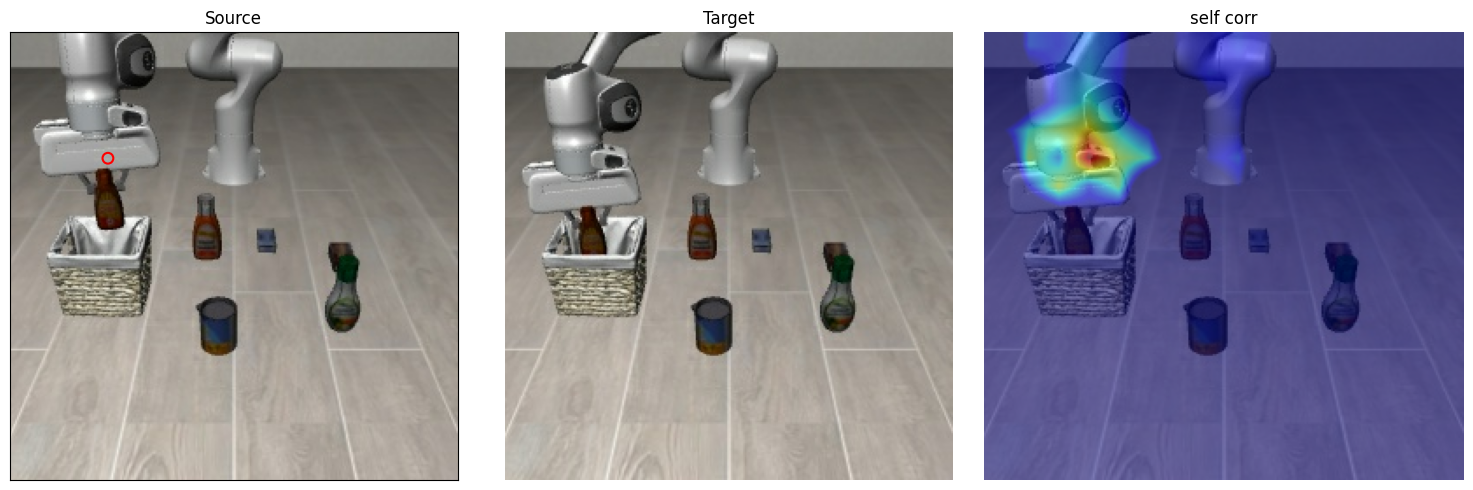

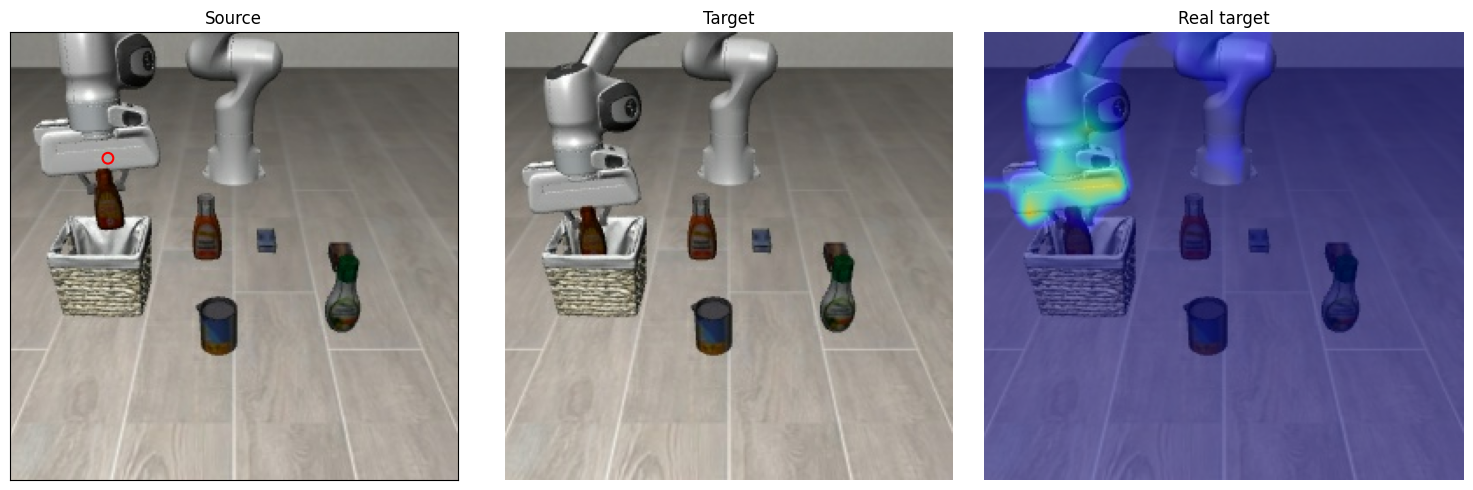

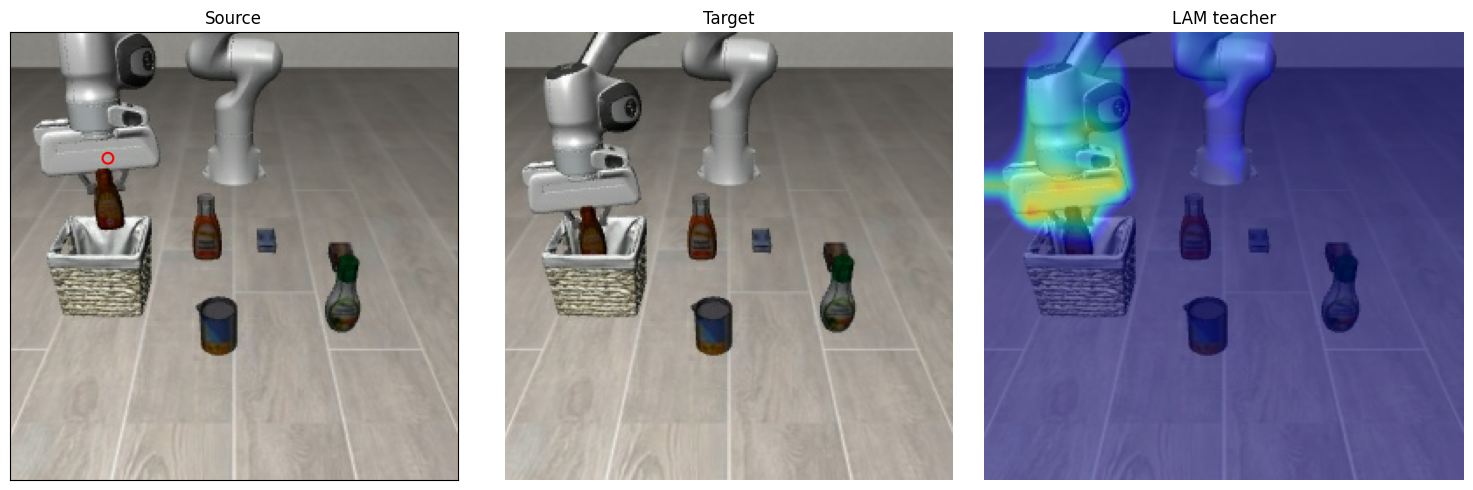

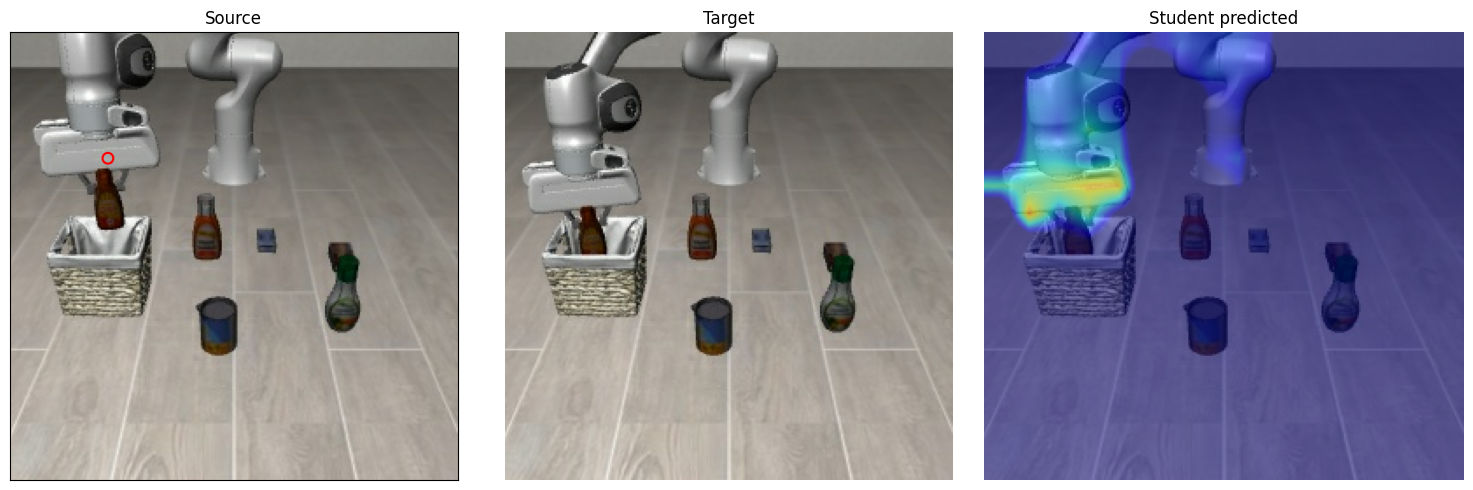

In [11]:
# 可视化当前 batch：原始帧 + 三种特征相似度热力图
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np

# 来自 test_dino.ipynb 的可视化函数

def _to_numpy_image(img):
    if isinstance(img, torch.Tensor):
        img = img.detach().cpu()
        if img.ndim == 3:
            img = img.permute(1, 2, 0)
        img = img.clip(0, 1).numpy()
    return img

def visualize_cross_image_similarity(src_feats, dst_feats, src_index=None, src_row=None, src_col=None,
                                      src_image=None, dst_image=None, cmap="jet", vmin=0.4, vmax=1.0,
                                      title=None, show_colorbar=False, src_title="Source", dst_title="Target", overlay_on_dst=True, alpha=0.5):
    if src_feats.dim() != 3 or dst_feats.dim() != 3:
        raise ValueError("src_feats 和 dst_feats 都需要是 [dim, H, W] 张量")
    dim_s, Hs, Ws = src_feats.shape
    dim_t, Ht, Wt = dst_feats.shape
    if dim_s != dim_t:
        raise ValueError(f"特征维不一致: src dim={dim_s}, dst dim={dim_t}")
    if src_index is not None:
        src_row = int(src_index) // Ws
        src_col = int(src_index) % Ws
    if src_row is None or src_col is None:
        raise ValueError("需要提供 src_index 或 (src_row, src_col) 其中之一")
    if not (0 <= src_row < Hs and 0 <= src_col < Ws):
        raise ValueError(f"(src_row, src_col)=({src_row}, {src_col}) 超出范围 Hs={Hs}, Ws={Ws}")
    src_feats_n = F.normalize(src_feats, p=2, dim=0)
    dst_feats_n = F.normalize(dst_feats, p=2, dim=0)
    anchor = src_feats_n[:, src_row, src_col]
    sim_map_tgt = (dst_feats_n * anchor.view(dim_s, 1, 1)).sum(dim=0).detach().cpu()

    # 计算画布数量：源图 + 目标图 + 热力图蒙皮
    num_imgs = int(src_image is not None) + int(dst_image is not None)
    cols = max(1, num_imgs + 1)  # 至少3列：源图、目标图、热力图
    fig, axes = plt.subplots(1, cols, figsize=(5 * cols, 5))
    ax_list = axes.flatten().tolist() if isinstance(axes, np.ndarray) else ([axes] if not isinstance(axes, (list, tuple)) else list(axes))
    idx = 0
    
    # 第一个画布：源图像 + 锚点标记
    if src_image is not None:
        ax_list[idx].imshow(_to_numpy_image(src_image), extent=[0, Ws, Hs, 0])
        ax_list[idx].scatter([src_col + 0.5], [src_row + 0.5], s=60, facecolors="none", edgecolors="red", linewidths=1.5)
        ax_list[idx].set_xlim(0, Ws)
        ax_list[idx].set_ylim(Hs, 0)
        ax_list[idx].set_xticks([])
        ax_list[idx].set_yticks([])
        ax_list[idx].set_title(src_title)
        idx += 1
    
    # 第二个画布：仅显示目标图像（无热力图蒙皮）
    if dst_image is not None:
        dst_img_np = _to_numpy_image(dst_image)
        ax_list[idx].imshow(dst_img_np)
        ax_list[idx].set_title(dst_title)
        ax_list[idx].axis('off')
        idx += 1
        
        # 第三个画布：目标图像 + 热力图蒙皮
        if overlay_on_dst:
            # 先显示原图
            ax_list[idx].imshow(dst_img_np)
            # 将热力图 resize 到与原图相同的尺寸
            img_h, img_w = dst_img_np.shape[:2]
            # 使用 torch 的 interpolate 将热力图 resize 到原图尺寸
            sim_map_resized = F.interpolate(
                sim_map_tgt.unsqueeze(0).unsqueeze(0),  # [1, 1, Ht, Wt]
                size=(img_h, img_w),
                mode='bilinear',
                align_corners=False
            ).squeeze().numpy()
            # 叠加热力图，使用 jet 配色（蓝色低值到红色高值，经典注意力图配色）
            im = ax_list[idx].imshow(sim_map_resized, cmap=cmap, vmin=vmin, vmax=vmax, 
                                     alpha=alpha, interpolation='bilinear', aspect='auto')
            # 使用 title 参数（如果提供），否则使用默认标题
            overlay_title = title if title is not None else f"{dst_title} (overlay)"
            ax_list[idx].set_title(overlay_title)
            ax_list[idx].axis('off')
            if show_colorbar:
                fig.colorbar(im, ax=ax_list[idx])
        idx += 1
    else:
        # 如果没有目标图像，只显示热力图
        im = ax_list[idx].imshow(sim_map_tgt.numpy(), cmap=cmap, vmin=vmin, vmax=vmax, aspect='auto')
        if title is None:
            title = f"Cross similarity — src(row={src_row}, col={src_col}) -> target"
        ax_list[idx].set_title(title)
        ax_list[idx].set_xlabel("w_patches")
        ax_list[idx].set_ylabel("h_patches")
        if show_colorbar:
            fig.colorbar(im, ax=ax_list[idx])
    plt.tight_layout()
    plt.show()
    plt.close()
    return sim_map_tgt

# ==== 准备特征 ====
# 重新跑一次 LAM 编码（开启 predict_future_frame 以拿到 recon）
with torch.no_grad():
    _run_out = latent_vla_model.lam._run(
        videos=model_inputs["lam_videos"],
        states=model_inputs["lam_states"],
        dec_videos=model_inputs["lam_videos"],
        dataset_ids=None,
        vq_training=False,
        predict_future_frame=True,
        return_vq_probs=False,
    )
recon_teacher, dec_in, tgt, perplexity, indices_teacher, s_pred, vision_features, quant_teacher, entropy_loss, vq_loss = _run_out
# 使用前边 cell 7 中已经获取的 LAM 特征
recon_teacher = recon_dino
# dec_in = dec_in_dino
# tgt = tgt_dino
# quant_teacher = quant_dino
# === Student decode: token-index path (VQ) or embedding path (supervise_quantized / AE) ===
vq = latent_vla_model.lam.vq

dec_states = model_inputs["lam_states"][:, : latent_vla_model.lam.frame_to_pre]
zeros_ds = torch.zeros(dec_states.shape[0], device=dec_states.device, dtype=torch.long)

recon_student = None
if getattr(latent_vla_model, "supervise_quantized", False):
    # embedding regression path: use pred_quantized (from Cell 5)
    quant_student = None
    try:
        quant_student = latency_compare.get("pred_quantized", None)
    except Exception:
        quant_student = None
    if quant_student is None:
        quant_student = out.get("pred_quantized", None) if isinstance(out, dict) else None
    if quant_student is None:
        raise ValueError("supervise_quantized=True but pred_quantized is missing; please run Cell 5 first.")
    quant_student = quant_student.to(device=dec_in.device, dtype=dec_in.dtype)
    recon_student = latent_vla_model.lam.decoder(
        features=dec_in,
        actions=quant_student,
    )
    # recon_student = lam.decoder(
    # features=dec_in,
    # actions=quant_teacher,
    # )
elif vq is not None:
    # token-index path: map predicted indices -> codebook -> out_proj -> decoder input_dim
    codebook = vq.get_codebooks()  # [K, code_dim]
    vlm_idx = out["vlm_latent_idx"].to(codebook.device)  # [B, Q]
    quant_vlm = codebook.index_select(0, vlm_idx.reshape(-1))  # [B*Q, code_dim]
    quant_vlm = vq.out_proj(quant_vlm).view(vlm_idx.shape[0], vlm_idx.shape[1], -1)  # -> [B, Q, input_dim]
    recon_student= latent_vla_model.lam.decoder(features=dec_in, actions=quant_vlm)
else:
    raise ValueError("LAM is in AE mode (lam.vq is None) but supervise_quantized=False; cannot map token indices to embeddings for decoding.")

# 用户可调：可视化的样本与 patch 位置
sample_idx = 4  # 修改这里选择 batch 中第几个样本
anchor_row = 4  # 修改为行号（0-based）；None 表示用 anchor_index 或居中
anchor_col = 3  # 修改为列号（0-based）；None 表示用 anchor_index 或居中
anchor_index = None  # 若设置整数，则优先生效（0..H*W-1）

# 取指定样本，提取 patch 特征（decoder 在当前配置下输出 latent patch 特征 [B,1,K,D]）
B0 = int(sample_idx)
H_grid = latent_vla_model.lam.encoder.grid_size
W_grid = latent_vla_model.lam.encoder.grid_size
D_feat = dec_in.shape[-1]

def patch_to_feat_patchfirst(t):
    # 输入可能是 [K, D] 或 [1, K, D]；返回 [D, H, W]
    if t.dim() == 3 and t.shape[0] == 1:
        t = t.squeeze(0)
    t = t.view(H_grid, W_grid, D_feat).permute(2, 0, 1)
    return t

src_feat = patch_to_feat_patchfirst(dec_in[B0])
tgt_feat = patch_to_feat_patchfirst(tgt[B0])
recon_teacher_feat = patch_to_feat_patchfirst(recon_teacher[B0])
recon_student_feat = patch_to_feat_patchfirst(recon_student[B0])



# 三张热力图：真实目标、LAM teacher、Student 预测（基于 latent patch 特征）
# 选择 anchor 位置（支持 anchor_index 或 row/col；否则居中）
if anchor_index is not None:
    anchor_index = int(anchor_index)
    anchor_row = anchor_index // W_grid
    anchor_col = anchor_index % W_grid
if anchor_row is None or anchor_col is None:
    anchor_row = H_grid // 2
    anchor_col = W_grid // 2
anchor_idx = anchor_row * W_grid + anchor_col

# Denormalize the chosen sample's first/last frames for visualization
_norm_mean = torch.tensor([0.485, 0.456, 0.406], device=lam_videos.device).view(3, 1, 1)
_norm_std = torch.tensor([0.229, 0.224, 0.225], device=lam_videos.device).view(3, 1, 1)
img0 = (lam_videos[B0, 0] * _norm_std + _norm_mean).clamp(0, 1).detach().cpu()
img1 = (lam_videos[B0, -1] * _norm_std + _norm_mean).clamp(0, 1).detach().cpu()
_ = visualize_cross_image_similarity(src_feat, src_feat, src_row=anchor_row, src_col=anchor_col, src_image=img0, dst_image=img1, title="self corr")
_ = visualize_cross_image_similarity(src_feat, tgt_feat, src_row=anchor_row, src_col=anchor_col, src_image=img0, dst_image=img1, title="Real target")
_ = visualize_cross_image_similarity(src_feat, recon_teacher_feat, src_row=anchor_row, src_col=anchor_col, src_image=img0, dst_image=img1, title="LAM teacher")
_ = visualize_cross_image_similarity(src_feat, recon_student_feat, src_row=anchor_row, src_col=anchor_col, src_image=img0, dst_image=img1, title="Student predicted")


In [9]:
print((recon_teacher-recon_dino).abs().mean())

tensor(0., device='cuda:0')


In [12]:
# 计算 src_feat 和 recon_student_feat 之间的余弦相似度
cos_sim = F.cosine_similarity(
    src_feat.flatten().unsqueeze(0), 
    recon_student_feat.flatten().unsqueeze(0), 
    dim=1
).item()
print(f"Cosine similarity between src_feat and recon_student_feat: {cos_sim:.4f}")

Cosine similarity between src_feat and recon_student_feat: 0.9344
